# AI Refund Assistant: LangGraph Visualization & Diagnostics

This notebook loads the compiled LangGraph agent, visualizes its structural flowchart, and allows you to trace the internal state machine step-by-step.

In [1]:
import os
import sys
from dotenv import load_dotenv
from IPython.display import Image, display

# Ensure the src directory is in the path to allow imports
project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.agent.agent import build_agent_graph

load_dotenv()
app = build_agent_graph()
print("LangGraph Agent Successfully Compiled!")

LangGraph Agent Successfully Compiled!


### 1. Visualizing the Graph Flow
LangGraph provides built-in methods to draw the architecture of your agent. We use Mermaid to render the nodes and conditional edges.

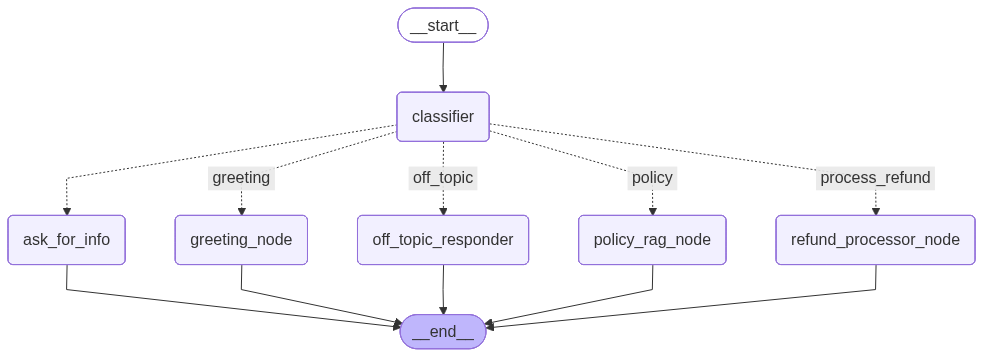

In [2]:
try:
    # Attempt to render as a visual PNG
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not generate PNG image. Displaying raw Mermaid syntax instead:")
    print("\n--- MERMAID SYNTAX ---\n")
    print(app.get_graph().draw_mermaid())

### 2. State Inspection & Flow Testing
Let's simulate a conversation turn and inspect exactly how the variables inside our `AgentState` TypedDict mutate as they pass through the nodes.

In [3]:
from langchain_core.messages import HumanMessage
import uuid

# 1. Define the initial state (simulating a user asking for a refund without providing an email)
initial_state = {
    "messages": [HumanMessage(content="I want to return my defective laptop.")],
    "intent": "",
    "customer_email": None,
    "current_order_id": None
}

config = {"configurable": {"thread_id": str(uuid.uuid4())}}

print("Invoking LangGraph...\n")
result_state = app.invoke(initial_state, config)

print("--- FINAL STATE TRACE ---")
print(f"Final Intent: '{result_state.get('intent')}'")
print(f"Extracted Email: {result_state.get('customer_email')}")
print(f"Extracted Order ID: {result_state.get('current_order_id')}")
print(f"\nAgent Response:\n{result_state['messages'][-1].content}")

Invoking LangGraph...

[DEBUG - Guardrails] Intent classified as: refund_request
--- FINAL STATE TRACE ---
Final Intent: 'refund_request'
Extracted Email: None
Extracted Order ID: None

Agent Response:
I can certainly help you with a refund. Could you please provide your email address first?
